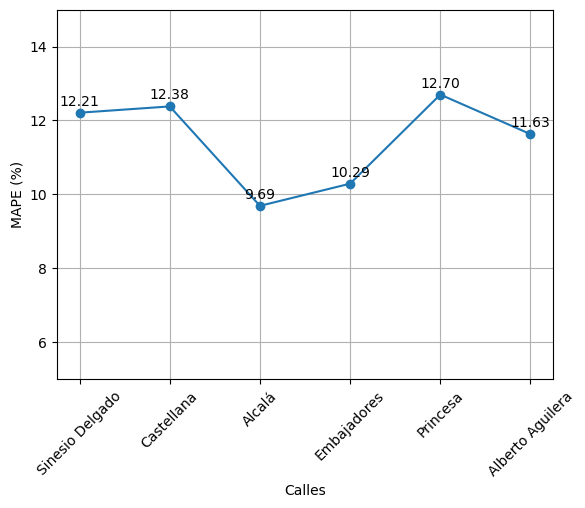

In [27]:
import matplotlib.pyplot as plt

# Datos
calles = [
    'Sinesio Delgado',
    'Castellana',
    'Alcalá',
    'Embajadores',
    'Princesa',
    'Alberto Aguilera'
]

mape = [12.21, 12.38, 9.69, 10.29, 12.70, 11.63]

plt.figure()
plt.plot(calles, mape, marker='o')

# Añadir valores en cada punto
for i, valor in enumerate(mape):
    plt.text(i, valor + 0.2, f'{valor:.2f}', ha='center')

plt.ylabel('MAPE (%)')
plt.xlabel('Calles')

plt.xticks(rotation=45)
plt.ylim(5, 15)

plt.grid()

# Guardar gráfico en la misma carpeta
plt.savefig('mape_por_calle_RF.png', dpi=300, bbox_inches='tight')

plt.show()

In [1]:
import pandas as pd

df = pd.DataFrame({
    'calle': [
        'Sinesio Delgado','Sinesio Delgado','Sinesio Delgado',
        'Castellana','Castellana','Castellana',
        'Alcala','Alcala','Alcala',
        'Embajadores','Embajadores','Embajadores',
        'Princesa','Princesa','Princesa',
        'Alberto Aguilera','Alberto Aguilera','Alberto Aguilera'
    ],
    'modelo': [
        'RF','XGBoost','SVR',
        'RF','XGBoost','SVR',
        'RF','XGBoost','SVR',
        'RF','XGBoost','SVR',
        'RF','XGBoost','SVR',
        'RF','XGBoost','SVR'
    ],
    'MAE': [
        39.72,35.94,37.04,
        66.99,67.13,81.37,
        74.67,68.34,69.30,
        49.93,50.31,50.77,
        35.55,36.17,36.61,
        92.90,88.09,90.94
    ],
    'RMSE': [
        58.62,52.78,53.23,
        98.49,96.14,113.68,
        127.33,117.53,116.49,
        68.49,67.99,74.16,
        53.87,52.96,53.83,
        191.81,184.95,184.97
    ],
    'MAPE': [
        12.21,12.03,12.60,
        12.38,12.44,15.91,
        9.69,8.88,9.68,
        10.29,10.29,10.11,
        12.70,12.62,12.64,
        11.63,10.81,11.23
    ]
})

In [3]:
df_mean = df.groupby('modelo')[['MAE', 'RMSE', 'MAPE']].mean().reset_index()
df_std = df.groupby('modelo')[['MAE', 'RMSE', 'MAPE']].std().reset_index()

print(df_mean)

    modelo        MAE       RMSE       MAPE
0       RF  59.960000  99.768333  11.483333
1      SVR  61.005000  99.393333  12.028333
2  XGBoost  57.663333  95.391667  11.178333


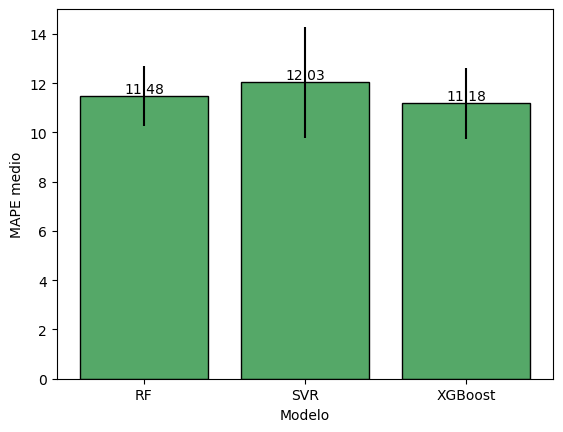

In [4]:
import matplotlib.pyplot as plt

plt.figure()

plt.bar(df_mean['modelo'], df_mean['MAPE'], yerr=df_std['MAPE'],
        color='#55A868', edgecolor='black')  # verde

plt.ylabel('MAPE medio')
plt.xlabel('Modelo')

for i, v in enumerate(df_mean['MAPE']):
    plt.text(i, v, str(round(v, 2)), ha='center', va='bottom')

plt.savefig('mape_modelos.png')
plt.show()

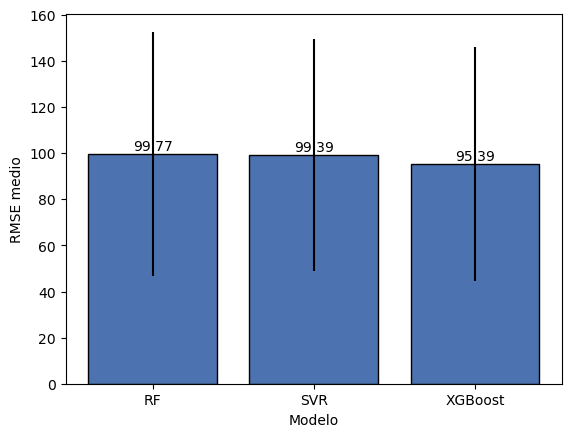

In [31]:
plt.figure()

plt.bar(df_mean['Modelo'], df_mean['RMSE'], yerr=df_std['RMSE'],
        color='#4C72B0', edgecolor='black')

plt.ylabel('RMSE medio')
plt.xlabel('Modelo')

for i, v in enumerate(df_mean['RMSE']):
    plt.text(i, v, str(round(v, 2)), ha='center', va='bottom')

plt.savefig('rmse_modelos.png')
plt.show()

<Figure size 640x480 with 0 Axes>

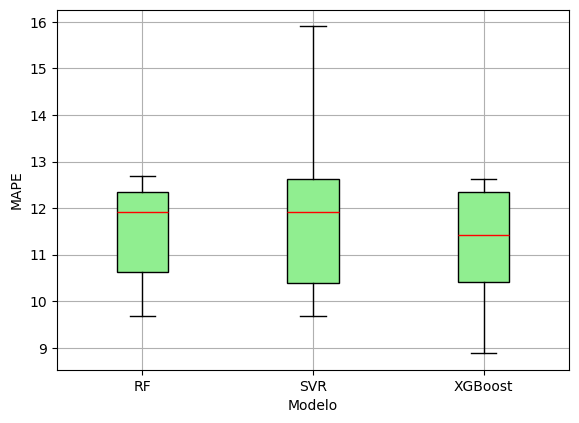

In [5]:
import matplotlib.pyplot as plt

plt.figure()

df.boxplot(
    column='MAPE',
    by='modelo',
    patch_artist=True,
    boxprops=dict(facecolor='lightgreen'),
    medianprops=dict(color='red'),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black')
)

plt.ylabel('MAPE')
plt.xlabel('Modelo')

plt.suptitle('')
plt.title('')

plt.savefig('boxplot_mape.png')
plt.show()

<Figure size 640x480 with 0 Axes>

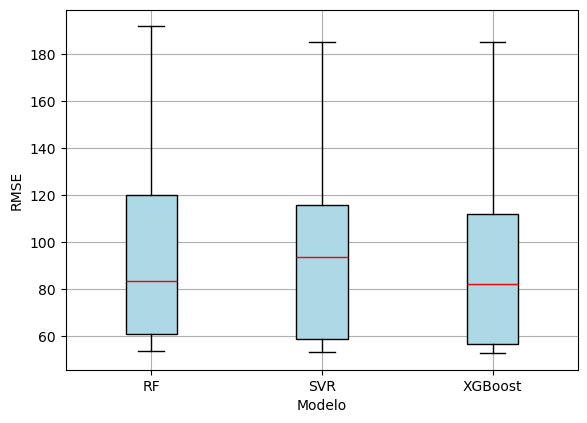

In [33]:
import matplotlib.pyplot as plt

plt.figure()

df.boxplot(
    column='RMSE',
    by='Modelo',
    patch_artist=True,
    boxprops=dict(facecolor='lightblue'),
    medianprops=dict(color='red'),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black')
)

plt.ylabel('RMSE')
plt.xlabel('Modelo')

plt.suptitle('')
plt.title('')

plt.savefig('boxplot_rmse.png')
plt.show()

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df_mape = pd.DataFrame({
    'calle': [
        'Sinesio Delgado',
        'Paseo de la Castellana',
        'Calle Alcalá',
        'Calle Embajadores',
        'Calle Princesa',
        'Calle Alberto Aguilera'
    ],
    'RF': [12.21, 12.38, 9.69, 10.29, 12.70, 11.63],
    'XGBoost': [12.03, 12.44, 8.88, 10.29, 12.62, 10.81],
    'SVR': [12.60, 15.91, 9.68, 10.11, 12.64, 11.23]
})

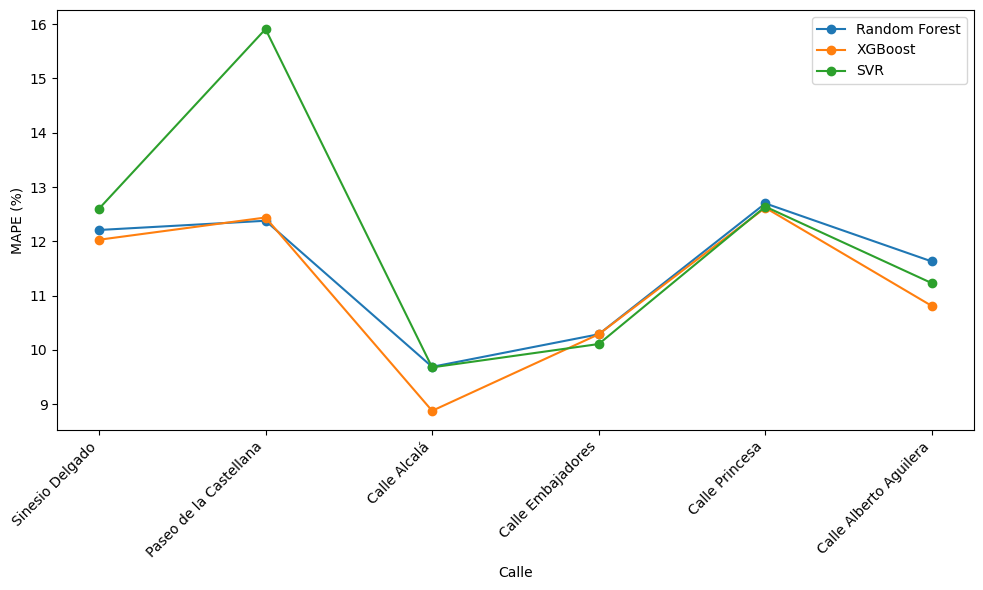

In [8]:
plt.figure(figsize=(10,6))

plt.plot(df_mape['calle'], df_mape['RF'], marker='o', label='Random Forest')
plt.plot(df_mape['calle'], df_mape['XGBoost'], marker='o', label='XGBoost')
plt.plot(df_mape['calle'], df_mape['SVR'], marker='o', label='SVR')

plt.ylabel('MAPE (%)')
plt.xlabel('Calle')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()

plt.savefig('mape_por_calle.png', dpi=300, bbox_inches='tight')
plt.show()

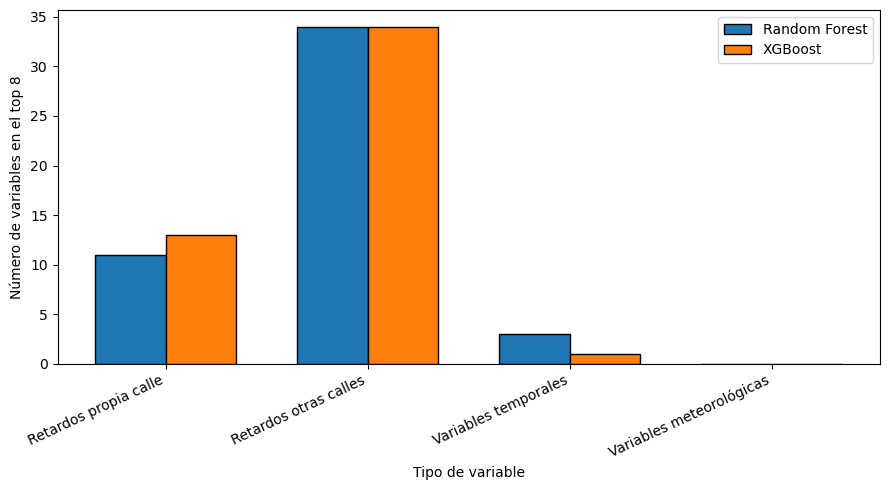

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df_tipos = pd.DataFrame({
    'Tipo de variable': [
        'Retardos propia calle',
        'Retardos otras calles',
        'Variables temporales',
        'Variables meteorológicas'
    ],
    'Random Forest': [11, 34, 3, 0],
    'XGBoost': [13, 34, 1, 0]
})

x = np.arange(len(df_tipos['Tipo de variable']))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(x - width/2, df_tipos['Random Forest'], width,
        label='Random Forest', edgecolor='black')

plt.bar(x + width/2, df_tipos['XGBoost'], width,
        label='XGBoost', edgecolor='black')

plt.xticks(x, df_tipos['Tipo de variable'], rotation=25, ha='right')
plt.ylabel('Número de variables en el top 8')
plt.xlabel('Tipo de variable')
plt.legend()

plt.tight_layout()
plt.savefig('tipos_variables_importancia.png', dpi=300, bbox_inches='tight')
plt.show()

In [13]:
import pandas as pd

df_porcentajes = pd.DataFrame({
    'Tipo de variable': [
        'Retardos propia calle',
        'Retardos otras calles',
        'Variables temporales',
        'Variables meteorológicas'
    ],
    'Random Forest': [52.03, 46.86, 1.11, 0.00],
    'XGBoost': [60.73, 37.50, 1.78, 0.00]
})

df_porcentajes

,Tipo de variable,Random Forest,XGBoost
0,Retardos propia calle,52.03,60.73
1,Retardos otras calles,46.86,37.50
2,Variables temporales,1.11,1.78
3,Variables meteorológicas,0.00,0.00


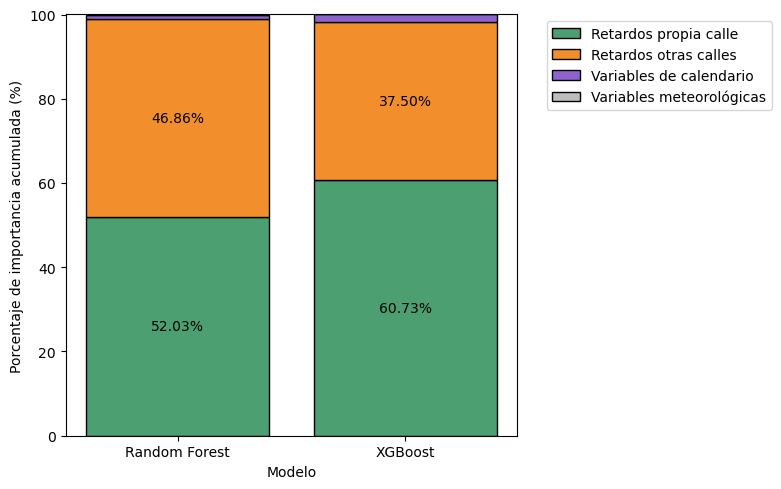

In [20]:
import matplotlib.pyplot as plt

rf = [52.03, 46.86, 1.11, 0.00]
xgb = [60.73, 37.50, 1.78, 0.00]

categorias = [
    'Retardos propia calle',
    'Retardos otras calles',
    'Variables de calendario',
    'Variables meteorológicas'
]

colores = ['#4C9F70', '#F28E2B', '#8E63CE', '#BDBDBD']

plt.figure(figsize=(8, 5))

bottom_rf = 0
bottom_xgb = 0

for i in range(len(categorias)):
    plt.bar('Random Forest', rf[i], bottom=bottom_rf,
            color=colores[i], edgecolor='black')
    plt.bar('XGBoost', xgb[i], bottom=bottom_xgb,
            color=colores[i], edgecolor='black')

    # Etiquetas solo en segmentos suficientemente grandes
    if rf[i] > 5:
        plt.text(0, bottom_rf + rf[i] / 2, f'{rf[i]:.2f}%',
                 ha='center', va='center', fontsize=10)
    if xgb[i] > 5:
        plt.text(1, bottom_xgb + xgb[i] / 2, f'{xgb[i]:.2f}%',
                 ha='center', va='center', fontsize=10)

    bottom_rf += rf[i]
    bottom_xgb += xgb[i]

handles = [
    plt.Rectangle((0, 0), 1, 1, color=colores[i], ec='black')
    for i in range(len(categorias))
]

plt.legend(handles, categorias, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.ylabel('Porcentaje de importancia acumulada (%)')
plt.xlabel('Modelo')

plt.tight_layout()
plt.savefig('porcentaje_importancia_tipos_apilado.png', dpi=300, bbox_inches='tight')
plt.show()

In [26]:
from pathlib import Path
import pandas as pd

rutas_importancias = [
    Path("../Modelos IA/importancias_variables"),
    Path("../XGBoost/importancias_variables")
]

archivos = []

for ruta in rutas_importancias:
    archivos.extend(list(ruta.glob("*.csv")))

print(f"Archivos encontrados: {len(archivos)}")

df_importancias = pd.concat(
    [pd.read_csv(archivo) for archivo in archivos],
    ignore_index=True
)

df_importancias["calle"] = df_importancias["calle"].replace({
    "Calle Alcala": "Calle Alcalá"
})

df_importancias

Archivos encontrados: 12


,feature,importance,modelo,calle
0,Calle Alberto Aguilera_O-E_t-1,362.135686,RF,Calle Alberto Aguilera
1,Calle Alberto Aguilera_E-O_t-1,68.604492,RF,Calle Alberto Aguilera
2,Paseo Infanta Isabel_E-O_t-3,5.601065,RF,Calle Alberto Aguilera
3,Calle Alberto Aguilera_O-E_t-2,4.286230,RF,Calle Alberto Aguilera
4,dia_semana,3.157217,RF,Calle Alberto Aguilera
...,...,...,...,...
721,Calle Velázquez_S-N_t-3,-0.234153,XGBoost,Paseo de la Castellana
722,Calle Hermanos García Noblejas_N-S_t-1,-0.393951,XGBoost,Paseo de la Castellana
723,Paseo de la Castellana_S-N_t-3,-0.541359,XGBoost,Paseo de la Castellana
724,Avenida Alfonso XIII_S-N_t-3,-0.550100,XGBoost,Paseo de la Castellana


In [27]:
df_importancias.groupby(["modelo", "calle"]).size()

modelo   calle                 
RF       Calle Alberto Aguilera    43
         Calle Alcalá              52
         Calle Embajadores         73
         Calle Princesa            43
         Calle Sinesio Delgado     73
         Paseo de la Castellana    79
XGBoost  Calle Alberto Aguilera    43
         Calle Alcalá              52
         Calle Embajadores         73
         Calle Princesa            43
         Calle Sinesio Delgado     73
         Paseo de la Castellana    79
dtype: int64

In [29]:
def clasificar_variable(feature, calle_objetivo):
    feature_lower = feature.lower()
    calle_lower = calle_objetivo.lower()

    # Variables meteorológicas
    if (
        "aemet" in feature_lower
        or "prec" in feature_lower
        or "tmed" in feature_lower
        or "temperatura" in feature_lower
        or "lluvia" in feature_lower
    ):
        return "Variables meteorológicas"

    # Variables de calendario
    if (
        "dia_semana" in feature_lower
        or "festivo" in feature_lower
        or "mes" in feature_lower
    ):
        return "Variables de calendario"

    # Retardos de la propia calle
    if calle_lower in feature_lower:
        return "Retardos propia calle"

    # Resto de retardos de tráfico
    return "Retardos otras calles"

In [30]:
df_importancias["tipo_variable"] = df_importancias.apply(
    lambda row: clasificar_variable(row["feature"], row["calle"]),
    axis=1
)

In [31]:
df_importancias["importance_pos"] = df_importancias["importance"].clip(lower=0)

In [32]:
df_cat = (
    df_importancias
    .groupby(["modelo", "calle", "tipo_variable"])["importance_pos"]
    .sum()
    .reset_index()
)

df_total = (
    df_cat
    .groupby(["modelo", "calle"])["importance_pos"]
    .sum()
    .reset_index()
    .rename(columns={"importance_pos": "total_importance"})
)

df_cat = df_cat.merge(df_total, on=["modelo", "calle"])

df_cat["porcentaje"] = 100 * df_cat["importance_pos"] / df_cat["total_importance"]

In [33]:
df_global = (
    df_cat
    .groupby(["modelo", "tipo_variable"])["porcentaje"]
    .mean()
    .reset_index()
)

df_global

,modelo,tipo_variable,porcentaje
0,RF,Retardos otras calles,54.875505
1,RF,Retardos propia calle,44.012369
2,RF,Variables de calendario,1.037662
3,RF,Variables meteorológicas,0.074464
4,XGBoost,Retardos otras calles,46.811721
5,XGBoost,Retardos propia calle,51.450323
6,XGBoost,Variables de calendario,1.626612
7,XGBoost,Variables meteorológicas,0.111344


In [34]:
orden = [
    "Retardos propia calle",
    "Retardos otras calles",
    "Variables de calendario",
    "Variables meteorológicas"
]

df_plot = df_global.pivot(
    index="modelo",
    columns="tipo_variable",
    values="porcentaje"
).fillna(0)

df_plot = df_plot[orden]

df_plot

tipo_variable,Retardos propia calle,Retardos otras calles,Variables de calendario,Variables meteorológicas
modelo,,,,
RF,44.012369,54.875505,1.037662,0.074464
XGBoost,51.450323,46.811721,1.626612,0.111344


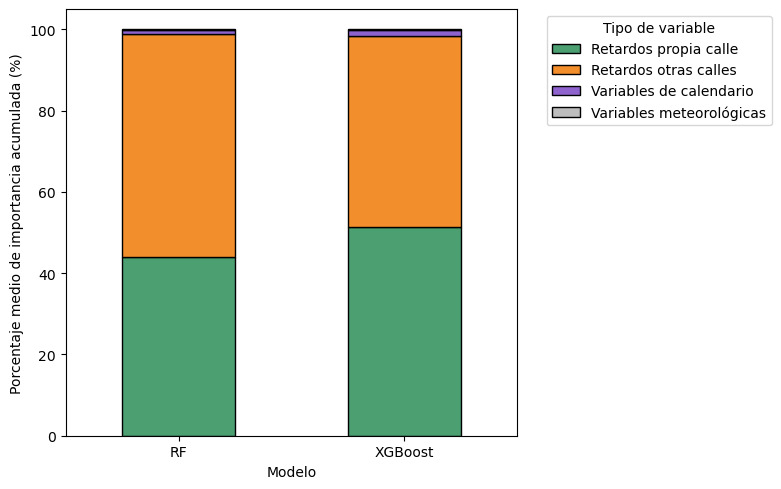

In [35]:
import matplotlib.pyplot as plt

colores = {
    "Retardos propia calle": "#4C9F70",
    "Retardos otras calles": "#F28E2B",
    "Variables de calendario": "#8E63CE",
    "Variables meteorológicas": "#BDBDBD"
}

ax = df_plot.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5),
    color=[colores[c] for c in orden],
    edgecolor="black"
)

plt.ylabel("Porcentaje medio de importancia acumulada (%)")
plt.xlabel("Modelo")
plt.xticks(rotation=0)
plt.legend(title="Tipo de variable", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.savefig("porcentaje_importancia_todas_variables.png", dpi=300, bbox_inches="tight")
plt.show()

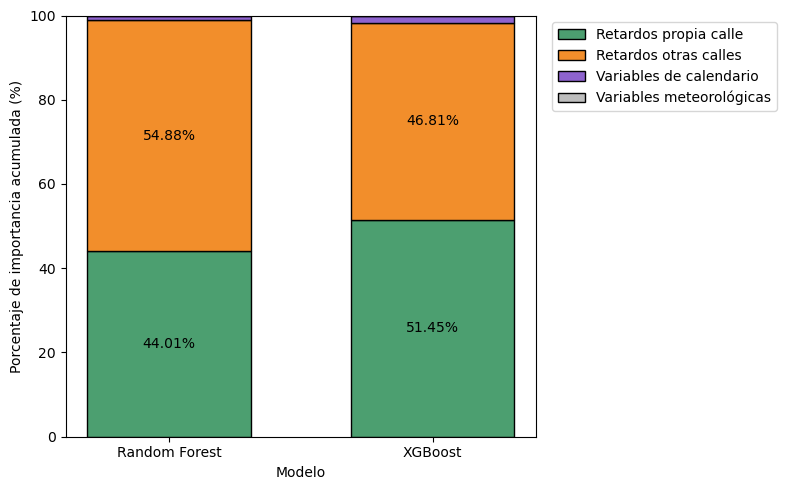

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# Asegura este orden
orden = [
    "Retardos propia calle",
    "Retardos otras calles",
    "Variables de calendario",
    "Variables meteorológicas"
]

# Si quieres que se vea igual que el otro, usa los mismos nombres en el índice
df_plot = df_plot.copy()
df_plot.index = ["Random Forest", "XGBoost"]

# Colores iguales al gráfico anterior
colores = {
    "Retardos propia calle": "#4C9F70",
    "Retardos otras calles": "#F28E2B",
    "Variables de calendario": "#8E63CE",
    "Variables meteorológicas": "#BDBDBD"
}

fig, ax = plt.subplots(figsize=(8, 5))  # mismo tamaño aprox.

x = np.arange(len(df_plot.index))
bottom = np.zeros(len(df_plot.index))

for categoria in orden:
    valores = df_plot[categoria].values

    ax.bar(
        x,
        valores,
        bottom=bottom,
        color=colores[categoria],
        edgecolor="black",
        width=0.62,   # parecido al del top 8
        label=categoria
    )

    # Mostrar porcentajes solo en segmentos suficientemente grandes
    for i, valor in enumerate(valores):
        if valor >= 5:
            ax.text(
                x[i],
                bottom[i] + valor / 2,
                f"{valor:.2f}%",
                ha="center",
                va="center",
                fontsize=10,
                color="black"
            )

    bottom += valores

# Ejes
ax.set_xticks(x)
ax.set_xticklabels(df_plot.index, fontsize=10)
ax.set_ylabel("Porcentaje de importancia acumulada (%)", fontsize=10)
ax.set_xlabel("Modelo", fontsize=10)

# Igual que en el otro: hasta 100, con un pequeño margen
ax.set_ylim(0, 100)

# Leyenda a la derecha, como en el top 8
ax.legend(
    title=None,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True
)

plt.tight_layout()
plt.savefig("porcentaje_importancia_todas_variables.png", dpi=300, bbox_inches="tight")
plt.show()